## Данные

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier, Pool
from matplotlib.patches import Patch
from scipy.stats import loguniform, randint, uniform
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score, make_scorer
from sklearn.model_selection import ParameterSampler, TimeSeriesSplit

from src.feature_generation import generate_features
from src.metric import pr_curve, precision_at_recall

pd.set_option("display.width", 1000)

SEED = 42

COMMON_PARAMS = {
    "task_type": "CPU",
    "loss_function": "Logloss",
    "random_seed": SEED,
    "allow_writing_files": False,  # не создавать папку catboost_info
}
BASE_PARAMS = {**COMMON_PARAMS, "iterations": 500, "depth": 5, "learning_rate": 0.03}

train = pd.read_csv(
    "data/train.csv",
    parse_dates=["cookie_created_at", "window_start_ts", "window_end_ts"],
)
test = pd.read_csv(
    "data/test.csv",
    parse_dates=["cookie_created_at", "window_start_ts", "window_end_ts"],
)
events = pd.read_csv("data/events.csv.gz", parse_dates=["event_ts"])

print(train.shape, test.shape, events.shape)
print("Доля ботов в train:", train.target.mean().round(4))
train.head()

(11091, 5) (4909, 4) (328905, 14)
Доля ботов в train: 0.0811


,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,0
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,0
3,ck_30ccd25bc1714ed9,2026-04-05 10:52:40,2026-04-06,2026-04-07,0
4,ck_a77c5f05948cdeef,2026-01-01 03:54:35,2026-04-06,2026-04-07,0


## Признаки

In [2]:
CAT_FEATURES = ["platform", "ua_os", "ua_browser", "ua_device", "ua_kind"]
# Можно дропнуть этот список наименее важных фичей и получить более простую модель
# при этом скор просядет примерно на 0.03
# drop_features = [
#     "n_ua_browser",
#     "ua_browser",
#     "n_ua",
#     "n_ua_os",
#     "dt_cv",
#     "ratio_ev_item_view",
#     "ptr_std_y",
#     "ratio_ev_login",
#     "ptr_std_y",
#     "ptr_mean_y",
#     "ratio_ev_search_results_view",
#     "ua_os",
#     "ratio_ev_contact_message_sent",
#     "ptr_mean_x",
#     "max_page",
#     "ua_device",
# ]
drop_features = []

CAT_FEATURES = list(set(CAT_FEATURES).difference(set(drop_features)))

train_sorted = train.sort_values("window_start_ts").reset_index(drop=True)
all_features = generate_features(events, train_sorted).drop(columns=drop_features)
all_target = train_sorted["target"]

# Пользуемся тем, что CatBoost сам умеет обрабатывать пропуски
all_features.isna().mean()

n_ua                             0.000000
n_ua_os                          0.000000
n_ua_browser                     0.000000
platform                         0.000000
ua_os                            0.000000
ua_browser                       0.000000
ua_device                        0.000000
ua_kind                          0.000000
max_page                         0.083040
mean_page                        0.083040
ptr_std_x                        0.646380
ptr_std_y                        0.646380
ptr_mean_x                       0.635200
ptr_mean_y                       0.635200
ptr_range_x                      0.635200
ptr_range_y                      0.635200
n_item_id                        0.000000
ratio_loc                        0.000000
ratio_cat                        0.000000
n_pointer_points                 0.000000
n_events                         0.000000
ratio_ev_item_view               0.000000
ratio_ev_search_results_view     0.000000
ratio_ev_photo_swipe             0

## Валидация

In [3]:
TEST_SIZE = 0.3
split_point = train_sorted.window_end_ts.quantile(1 - TEST_SIZE)
is_train = (train_sorted.window_end_ts <= split_point).to_numpy()
is_val = (train_sorted.window_start_ts >= split_point).to_numpy()

data_train, data_val = train_sorted[is_train], train_sorted[is_val]
X_train, y_train = all_features[is_train], all_target[is_train]
X_val, y_val = all_features[is_val], all_target[is_val]

lost = len(train_sorted) - len(data_train) - len(data_val)
print("Потеряли строк при разбиении на train/val", lost, lost / len(train_sorted))
print("Реальный test_size", len(data_val) / (len(data_train) + len(data_val)))
print("Train", data_train["target"].value_counts(normalize=True).round(4))
print("Validation", data_val["target"].value_counts(normalize=True).round(4))
# Доли ботов в train и validation почти равны

Потеряли строк при разбиении на train/val 0 0.0
Реальный test_size 0.24262915877738708
Train target
0    0.9192
1    0.0808
Name: proportion, dtype: float64
Validation target
0    0.9182
1    0.0818
Name: proportion, dtype: float64


## Базовая модель на holdout

Базовая конфигурация CatBoost с фиксированным числом итераций. Ранней остановки по holdout нет, чтобы оценка на нём оставалась честной.

In [4]:
train_pool = Pool(X_train, y_train, cat_features=CAT_FEATURES)
test_pool = Pool(X_val, y_val, cat_features=CAT_FEATURES)

base_model = CatBoostClassifier(**BASE_PARAMS)
base_model.fit(train_pool, verbose=100)

p_va = base_model.predict_proba(test_pool)[:, 1]
print("P@R0.7 на валидации:", round(precision_at_recall(y_val, p_va), 4))
print("доля ботов (это уровень константы):", round(y_val.mean(), 4))

0:	learn: 0.6563939	total: 51.5ms	remaining: 25.7s
100:	learn: 0.1466752	total: 397ms	remaining: 1.58s
200:	learn: 0.1222034	total: 770ms	remaining: 1.16s
300:	learn: 0.1099454	total: 1.15s	remaining: 770ms
400:	learn: 0.1010303	total: 1.52s	remaining: 380ms
499:	learn: 0.0934608	total: 1.9s	remaining: 0us
P@R0.7 на валидации: 0.7476
доля ботов (это уровень константы): 0.0818


### Сравнение со случайной моделью

Проводим сравнение Dummy-моделей с полученной.
Также проведём bootstrap по кукам, посмотрим насколько гуляет метрика самой модели.

In [5]:
def scores(y, p):
    return {
        "P@R0.7": precision_at_recall(y, p),
        "PR-AUC": average_precision_score(y, p),
    }


results = {"CatBoost": scores(y_val, p_va)}
dummy_p = {}
for strategy in ["most_frequent", "stratified"]:
    dummy = DummyClassifier(strategy=strategy, random_state=0).fit(X_train, y_train)
    dummy_p[strategy] = dummy.predict_proba(X_val)[:, 1]
    results[f"Dummy({strategy})"] = scores(y_val, dummy_p[strategy])


rng = np.random.default_rng(0)
y_true = y_val.to_numpy()

boot = np.array(
    [
        precision_at_recall(y_true[i], p_va[i])
        for i in (rng.integers(0, len(y_true), len(y_true)) for _ in range(1000))
    ]
)
lo, hi = np.quantile(boot, [0.025, 0.975])


print(f"P@R0.7 модели: {results['CatBoost']['P@R0.7']:.3f}, 95% bootstrap-интервал [{lo:.3f}, {hi:.3f}]")
print(pd.DataFrame(results).T.round(3))

P@R0.7 модели: 0.748, 95% bootstrap-интервал [0.601, 0.840]
                      P@R0.7  PR-AUC
CatBoost               0.748   0.762
Dummy(most_frequent)   0.082   0.082
Dummy(stratified)      0.082   0.080


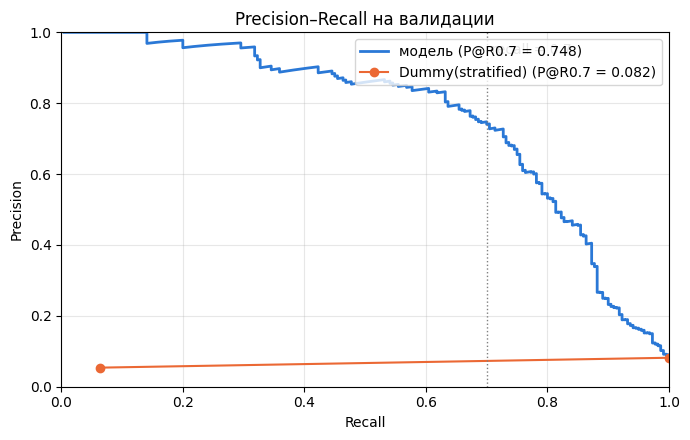

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))

prec, rec = pr_curve(y_val, p_va)
ax.plot(
    rec,
    prec,
    color="#2a78d6",
    lw=2,
    label=f"модель (P@R0.7 = {results['CatBoost']['P@R0.7']:.3f})",
)

prec_d, rec_d = pr_curve(y_val, dummy_p["stratified"])
ax.plot(
    rec_d,
    prec_d,
    color="#eb6834",
    lw=1.5,
    marker="o",
    label=f"Dummy(stratified) (P@R0.7 = {results['Dummy(stratified)']['P@R0.7']:.3f})",
)

ax.axvline(0.7, color="gray", ls=":", lw=1)
ax.text(0.7, 0.97, " recall = 0.7", color="gray", va="top")
ax.set(
    xlabel="Recall",
    ylabel="Precision",
    xlim=(0, 1),
    ylim=(0, 1),
    title="Precision–Recall на валидации",
)
ax.grid(alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

### Ранние эксперименты

До перехода на кросс-валидацию модель обучалась с ранней остановкой по этому же holdout, на ранних версиях признаков. P@R0.7 на holdout и 95% bootstrap-интервал:

| depth | метрика ранней остановки | веса классов | P@R0.7 |
|---|---|---|---|
| 8 | F1 | Balanced | 0.453 [0.358, 0.576] |
| 8 | F1 | Balanced | 0.510 [0.386, 0.686] |
| 8 | PRAUC | Balanced | 0.589 [0.487, 0.697] |
| 8 | P@R0.7 | Balanced | 0.614 [0.510, 0.698] |
| 8 | P@R0.7 | нет | 0.650 [0.490, 0.726] |
| 10 | F1 | Balanced | 0.609 [0.451, 0.679] |
| 10 | P@R0.7 | Balanced | 0.618 [0.478, 0.693] |
| 10 | P@R0.7 | нет | 0.627 [0.496, 0.694] |
| 6 | P@R0.7 | нет | 0.606 [0.484, 0.698] |
| 5 | P@R0.7 | нет | 0.631 [0.479, 0.704] |

Выводы:
- F1 для ранней остановки не подходит: он не связан с P@R0.7 и модель останавливалась слишком рано
- различия между остальными вариантами минимальны и почти не различимы
- ранняя остановка по тому же holdout, на котором считается метрика, завышает оценку

Поэтому дальше используется фиксированное число итераций, а конфигурации сравниваются на кросс-валидации.

### Важность признаков

Сначала посмотрим, какие признаки модель посчитала самыми важными во время обучения.

И посмотрим permutation importance на отложенной выборке, чтобы оценить насколько падает PR-AUC, если перемешать признак, то есть помогает ли он на новых данных.
Используем PR-AUC, чтобы модель оценивала по всем данным. Если фича сильно влияет на PR-AUC, то и на P@R0.7 тоже.

На основе permutation importance и происходил выбор кандидатов в drop_features.

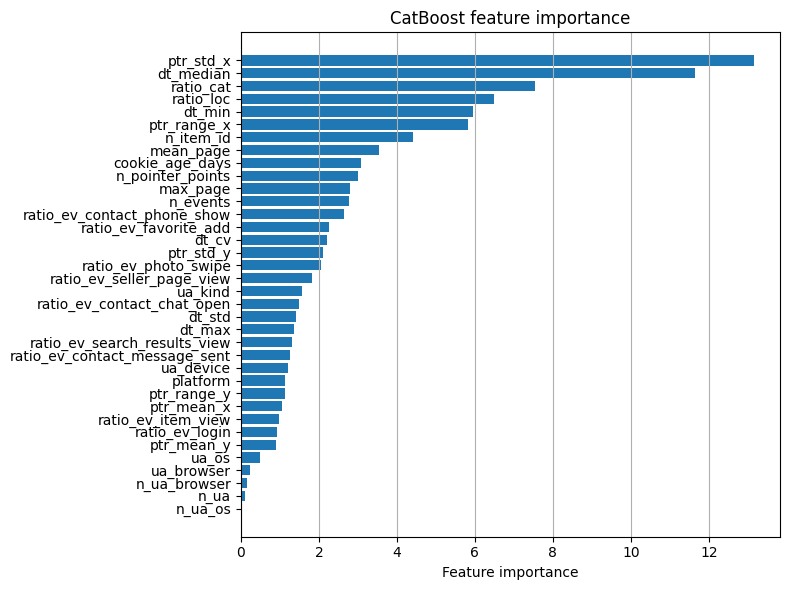

In [7]:
feature_importances = base_model.get_feature_importance(train_pool)
feature_names = X_train.columns

fi_df = pd.DataFrame({"feature": feature_names, "importance": feature_importances})

fi_df = fi_df.sort_values("importance", ascending=False).reset_index(drop=True)
fi_df.head()

plt.figure(figsize=(8, 6))

plt.barh(fi_df["feature"], fi_df["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Feature importance")
plt.title("CatBoost feature importance")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

In [8]:
N_REPEATS = 20
p_at_r_scorer = make_scorer(precision_at_recall, response_method="predict_proba")

pi = permutation_importance(
    base_model,
    X_val,
    y_val,
    scoring="average_precision",
    n_repeats=N_REPEATS,
    random_state=0,
)

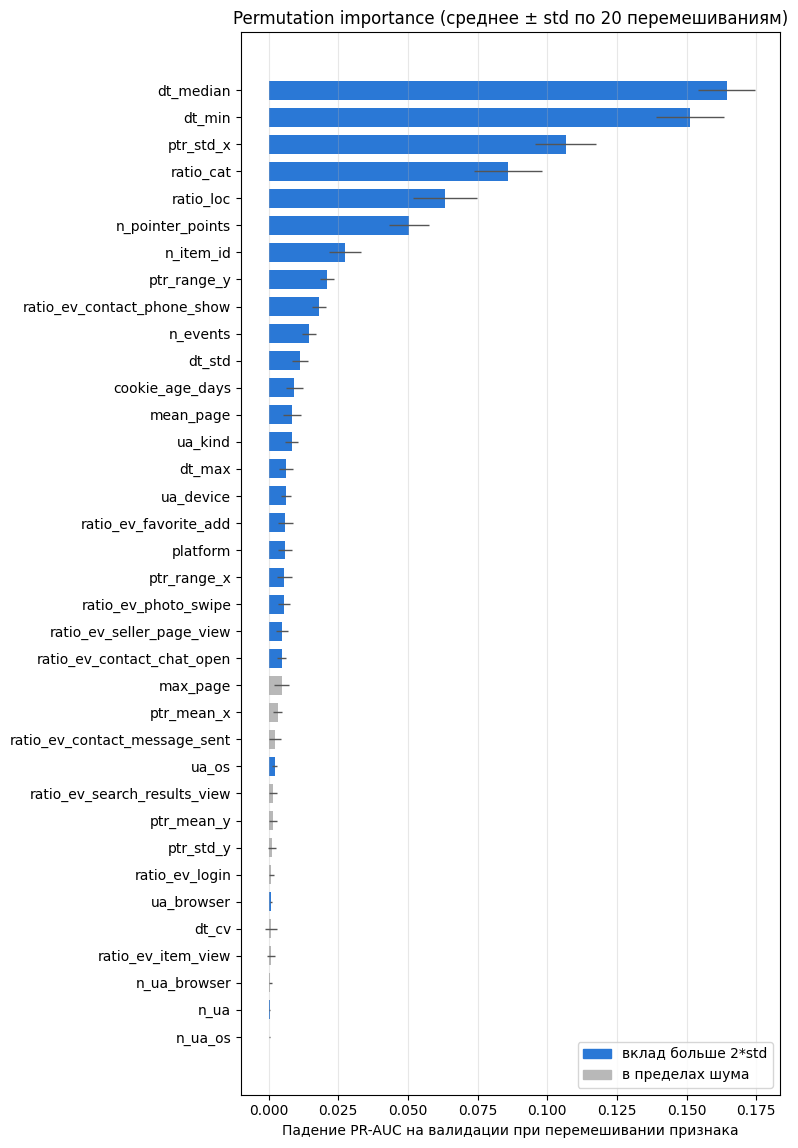

In [9]:
pi_df = pd.DataFrame(
    {"mean": pi.importances_mean, "std": pi.importances_std}, index=X_val.columns
).sort_values("mean")

# вклад заметно больше шума перемешиваний
pi_df["significant"] = pi_df["mean"] > 2 * pi_df["std"]

fig, ax = plt.subplots(figsize=(8, 0.28 * len(pi_df) + 1.5))
ax.barh(
    pi_df.index,
    pi_df["mean"],
    xerr=pi_df["std"],
    height=0.7,
    color=np.where(pi_df["significant"], "#2a78d6", "#b8b8b8"),
    error_kw={"ecolor": "#555555", "elinewidth": 1},
)
ax.set(
    xlabel="Падение PR-AUC на валидации при перемешивании признака",
    title=f"Permutation importance (среднее ± std по {N_REPEATS} перемешиваниям)",
)
ax.grid(axis="x", alpha=0.3)
ax.legend(
    handles=[
        Patch(color="#2a78d6", label="вклад больше 2*std"),
        Patch(color="#b8b8b8", label="в пределах шума"),
    ],
    loc="lower right",
)
plt.tight_layout()
plt.show()

### Разбор ошибок базовой модели

Просмотр ответов модели и вывод семплов, на которых она ошиблась для анализа промахов и построения новых признаков.


Выбираем порог, который максимизирует P@R0.7, по нему каждая кука из валидации получает тип: 
- TP - найденный бот
- FN - пропущенный бот
- FP - человек, принятый за бота
- TN - человек

In [10]:
def show_cookie(cookie_id):
    """Сырые события куки внутри её окна наблюдения."""
    meta = train.set_index("cookie_id").loc[cookie_id]
    ev = events[
        (events.cookie_id == cookie_id)
        & (events.event_ts >= meta.window_start_ts)
        & (events.event_ts < meta.window_end_ts)
    ]
    cols = [
        "event_ts",
        "event_name",
        "platform",
        "item_category",
        "item_location",
        "search_query",
        "search_page",
        "pointer_x",
        "pointer_y",
        "user_agent",
    ]
    return ev.sort_values("event_ts")[cols]

In [11]:
prec, rec = pr_curve(y_val, p_va)
thresholds = np.unique(p_va)[::-1]
best = np.argmax(np.where(rec >= 0.7, prec, -1))
threshold = thresholds[best]
val_pred = (p_va >= threshold).astype(int)

print(
    f"порог: {threshold:.4f}, precision {y_val[val_pred == 1].mean():.3f}, recall {val_pred[y_val == 1].mean():.3f}"
)

порог: 0.2333, precision 0.748, recall 0.700


In [12]:
# TP - найденный бот, FN - пропущенный бот, FP - человек, принятый за бота, TN - человек
errors = X_val.copy()
errors["target"] = y_val.to_numpy()
errors["score"] = p_va
errors["pred"] = val_pred
errors["error_type"] = np.select(
    [
        (errors.target == 1) & (errors.pred == 1),
        (errors.target == 0) & (errors.pred == 1),
        (errors.target == 1) & (errors.pred == 0),
    ],
    ["TP", "FP", "FN"],
    default="TN",
)

print(errors["error_type"].value_counts(), "\n\n")
missed_bots = errors[errors["error_type"] == "FN"]
missed_bots = missed_bots.sort_values("score", ascending=False)
false_bots = errors[errors["error_type"] == "FP"]
false_bots = false_bots.sort_values("score")

print("Пропущенные боты")
print(missed_bots.head(10), "\n")
print("Люди, принятые за ботов")
print(false_bots.head(10))

error_type
TN    2419
TP     154
FN      66
FP      52
Name: count, dtype: int64 


Пропущенные боты
                     n_ua  n_ua_os  n_ua_browser platform    ua_os ua_browser ua_device          ua_kind  max_page  mean_page  ...  dt_median       dt_std  dt_max  dt_min     dt_cv  cookie_age_days  target     score  pred  error_type
cookie_id                                                                                                                      ...                                                                                                       
ck_2cae8906eb5786e0     1        1             1  android  android  avito_app  M2101K6G              app       6.0   4.000000  ...       17.0  2565.983199  7717.0     4.0  2.934415        47.009329       1  0.229184     0          FN
ck_8be4011b99bce80b     1        1             1  android  android  avito_app  SM-A125F              app       9.0   3.062500  ...       20.0   718.372088  3722.0     2.0  3.174833        84.492500

In [13]:
ind = 0
print(missed_bots.iloc[ind])
show_cookie(missed_bots.index[ind])

n_ua                                       1
n_ua_os                                    1
n_ua_browser                               1
platform                             android
ua_os                                android
ua_browser                         avito_app
ua_device                           M2101K6G
ua_kind                                  app
max_page                                 6.0
mean_page                                4.0
ptr_std_x                                NaN
ptr_std_y                                NaN
ptr_mean_x                               NaN
ptr_mean_y                               NaN
ptr_range_x                              NaN
ptr_range_y                              NaN
n_item_id                                  4
ratio_loc                                0.3
ratio_cat                                0.2
n_pointer_points                           0
n_events                                  10
ratio_ev_item_view                       0.5
ratio_ev_s

,event_ts,event_name,platform,item_category,item_location,search_query,search_page,pointer_x,pointer_y,user_agent
138674,2026-04-19 01:56:24,search_results_view,ANDROID,avtomobili,moskva,renault logan,2.0,NaN,NaN,Avito/120.0 (Android 12; M2101K6G) okhttp/4.11.0
8520,2026-04-19 01:57:04,item_view,Android,avtomobili,moskva,NaN,NaN,NaN,NaN,Avito/120.0 (Android 12; M2101K6G) okhttp/4.11.0
207108,2026-04-19 01:57:26,seller_page_view,Android,avtomobili,chelyabinsk,NaN,NaN,NaN,NaN,Avito/120.0 (Android 12; M2101K6G) okhttp/4.11.0
237433,2026-04-19 01:57:30,search_results_view,android,uslugi,samara,маникюр,4.0,NaN,NaN,Avito/120.0 (Android 12; M2101K6G) okhttp/4.11.0
269602,2026-04-19 01:57:47,item_view,Android,avtomobili,moskva,NaN,NaN,NaN,NaN,Avito/120.0 (Android 12; M2101K6G) okhttp/4.11.0
149393,2026-04-19 04:06:24,search_results_view,ANDROID,avtomobili,moskva,лада гранта,6.0,NaN,NaN,Avito/120.0 (Android 12; M2101K6G) okhttp/4.11.0
221607,2026-04-19 04:06:31,item_view,Android,avtomobili,moskva,NaN,NaN,NaN,NaN,Avito/120.0 (Android 12; M2101K6G) okhttp/4.11.0
64040,2026-04-19 04:06:45,item_view,android,uslugi,moskva,NaN,NaN,NaN,NaN,Avito/120.0 (Android 12; M2101K6G) okhttp/4.11.0
280773,2026-04-19 04:07:17,item_view,Android,avtomobili,NaN,NaN,NaN,NaN,NaN,Avito/120.0 (Android 12; M2101K6G) okhttp/4.11.0
157874,2026-04-19 04:07:34,favorite_add,ANDROID,avtomobili,moskva,NaN,NaN,NaN,NaN,Avito/120.0 (Android 12; M2101K6G) okhttp/4.11.0


In [14]:
ind = 0
print(false_bots.iloc[ind])
show_cookie(false_bots.index[ind])

n_ua                                       1
n_ua_os                                    1
n_ua_browser                               1
platform                             android
ua_os                                android
ua_browser                         avito_app
ua_device                           SM-A515F
ua_kind                                  app
max_page                                 3.0
mean_page                           1.666667
ptr_std_x                                NaN
ptr_std_y                                NaN
ptr_mean_x                               NaN
ptr_mean_y                               NaN
ptr_range_x                              NaN
ptr_range_y                              NaN
n_item_id                                  3
ratio_loc                           0.666667
ratio_cat                           0.166667
n_pointer_points                           0
n_events                                   6
ratio_ev_item_view                  0.333333
ratio_ev_s

,event_ts,event_name,platform,item_category,item_location,search_query,search_page,pointer_x,pointer_y,user_agent
137216,2026-04-19 10:13:24,item_view,Android,hobbi,tyumen,NaN,NaN,NaN,NaN,Avito/120.0 (Android 11; SM-A515F) okhttp/4.11.0
3003,2026-04-19 10:13:28,search_results_view,Android,hobbi,NaN,коньки,1.0,NaN,NaN,Avito/120.0 (Android 11; SM-A515F) okhttp/4.11.0
13894,2026-04-19 10:13:30,item_view,android,hobbi,volgograd,NaN,NaN,NaN,NaN,Avito/120.0 (Android 11; SM-A515F) okhttp/4.11.0
273928,2026-04-19 10:13:32,search_results_view,Android,hobbi,sankt-peterburg,коньки,1.0,NaN,NaN,Avito/120.0 (Android 11; SM-A515F) okhttp/4.11.0
226305,2026-04-19 10:17:27,seller_page_view,ANDROID,hobbi,makhachkala,NaN,NaN,NaN,NaN,Avito/120.0 (Android 11; SM-A515F) okhttp/4.11.0
205422,2026-04-19 12:41:07,search_results_view,android,hobbi,tyumen,коньки,3.0,NaN,NaN,Avito/120.0 (Android 11; SM-A515F) okhttp/4.11.0


### Промежуточный сабмит базовой модели

In [15]:
test_features = generate_features(events, test).drop(columns=drop_features)
sub = pd.DataFrame(
    {
        "cookie_id": test["cookie_id"],
        "score": base_model.predict_proba(Pool(test_features, cat_features=CAT_FEATURES))[:, 1],
    }
)
assert len(sub) == len(test) and sub.score.between(0, 1).all()
sub.to_csv("submissions/base_catboost_sub.csv", index=False)
sub.head()

,cookie_id,score
0,ck_315fb710a0e371e7,0.002393
1,ck_a76ee3b3e3e522fd,0.072790
2,ck_94c9a4d382689e82,0.016466
3,ck_8eaf9509ad9462a0,0.002280
4,ck_9a88a5a989cb5bc6,0.009654


## Кросс-валидация по времени

Используем `TimeSeriesSplit(5)` по отсортированному по времени train: каждый фолд учится на всех более ранних куках и проверяется на следующих. На каждом фолде считаются P@R0.7 и PR-AUC. PR-AUC используем как вспомогательную метрику для оценки адекватности полученного P@R0.7.

In [16]:
def cv_catboost(features, target, params, cat_features, n_splits=5, verbose=False):
    """Оценка CatBoost на временных фолдах (expanding window).

    features и target должны идти в одном порядке и быть отсортированы по window_start_ts
    """
    target = np.asarray(target)
    tscv = TimeSeriesSplit(n_splits=n_splits)

    rows = []
    for fold, (train_idx, val_idx) in enumerate(tscv.split(features)):
        X_tr, y_tr = features.iloc[train_idx], target[train_idx]
        X_va, y_va = features.iloc[val_idx], target[val_idx]

        model = CatBoostClassifier(**params)
        model.fit(Pool(X_tr, y_tr, cat_features=cat_features), verbose=verbose)
        p = model.predict_proba(Pool(X_va, cat_features=cat_features))[:, 1]

        rows.append(
            {
                "fold": fold,
                "n_bots": int(y_va.sum()),
                "P@R0.7": precision_at_recall(y_va, p),
                "PR-AUC": average_precision_score(y_va, p),
            }
        )
    return pd.DataFrame(rows).set_index("fold")


cv_res = cv_catboost(all_features, all_target, BASE_PARAMS, CAT_FEATURES)
display(cv_res)
cv_res.agg(["mean", "std"])

,n_bots,P@R0.7,PR-AUC
fold,,,
0,135,0.616883,0.736739
1,173,0.616162,0.743509
2,137,0.680851,0.761703
3,148,0.615385,0.746538
4,151,0.768116,0.786340


,n_bots,P@R0.7,PR-AUC
mean,148.800000,0.659479,0.754966
std,15.172343,0.066884,0.019775


## Random Search

Подбираем лучшие параметры для CatBoost с помощью Random Search и оцениваем каждую конфигурацию с помощью кросс-валидации из прошлого раздела.
Лучшая конфигурация выбирается по среднему P@R0.7.

In [17]:
param_distributions = {
    "depth": randint(4, 9),
    "learning_rate": loguniform(0.01, 0.1),
    "iterations": [300, 500, 800, 1200],
    "l2_leaf_reg": loguniform(1, 30),
    "random_strength": loguniform(0.1, 10),  # шум при выборе сплитов
    "subsample": uniform(0.6, 0.4),  # доля объектов на итерацию: 0.6-1.0
    "rsm": uniform(0.5, 0.5),  # доля признаков на сплит: 0.5-1.0
    "auto_class_weights": [None, "Balanced"],
}

N_ITER = 40
search_results = []
for i, sampled in enumerate(ParameterSampler(param_distributions, n_iter=N_ITER, random_state=42)):
    params = {**COMMON_PARAMS, **sampled}
    start = time.time()
    res = cv_catboost(all_features, all_target, params, CAT_FEATURES)
    search_results.append(
        {
            **sampled,
            "PR-AUC_mean": res["PR-AUC"].mean(),
            "PR-AUC_std": res["PR-AUC"].std(),
            "P@R_mean": res["P@R0.7"].mean(),
            "P@R_std": res["P@R0.7"].std(),
            "sec": time.time() - start,
            "params": params,
        }
    )
    print(f"{i + 1:2d}/{N_ITER}  PR-AUC {res['PR-AUC'].mean():.3f}  P@R0.7 {res['P@R0.7'].mean():.3f}")

search_df = pd.DataFrame(search_results).sort_values("PR-AUC_mean", ascending=False).reset_index(drop=True)
print("Готово!")

 1/40  PR-AUC 0.757  P@R0.7 0.681
 2/40  PR-AUC 0.754  P@R0.7 0.657
 3/40  PR-AUC 0.750  P@R0.7 0.678
 4/40  PR-AUC 0.759  P@R0.7 0.664
 5/40  PR-AUC 0.754  P@R0.7 0.682
 6/40  PR-AUC 0.752  P@R0.7 0.662
 7/40  PR-AUC 0.734  P@R0.7 0.610
 8/40  PR-AUC 0.744  P@R0.7 0.675
 9/40  PR-AUC 0.751  P@R0.7 0.661
10/40  PR-AUC 0.760  P@R0.7 0.694
11/40  PR-AUC 0.744  P@R0.7 0.674
12/40  PR-AUC 0.713  P@R0.7 0.556
13/40  PR-AUC 0.749  P@R0.7 0.683
14/40  PR-AUC 0.753  P@R0.7 0.673
15/40  PR-AUC 0.743  P@R0.7 0.656
16/40  PR-AUC 0.758  P@R0.7 0.683
17/40  PR-AUC 0.708  P@R0.7 0.570
18/40  PR-AUC 0.753  P@R0.7 0.690
19/40  PR-AUC 0.751  P@R0.7 0.687
20/40  PR-AUC 0.750  P@R0.7 0.648
21/40  PR-AUC 0.733  P@R0.7 0.613
22/40  PR-AUC 0.741  P@R0.7 0.631
23/40  PR-AUC 0.747  P@R0.7 0.656
24/40  PR-AUC 0.748  P@R0.7 0.655
25/40  PR-AUC 0.714  P@R0.7 0.599
26/40  PR-AUC 0.752  P@R0.7 0.669
27/40  PR-AUC 0.750  P@R0.7 0.655
28/40  PR-AUC 0.762  P@R0.7 0.721
29/40  PR-AUC 0.730  P@R0.7 0.627
30/40  PR-AUC 

In [18]:
print(
    f"Базовая конфигурация: PR-AUC {cv_res['PR-AUC'].mean():.3f}  P@R0.7 {cv_res['P@R0.7'].mean():.3f}, std:{cv_res['P@R0.7'].std():.3f}"
)
search_df.drop(columns="params").sort_values("P@R_mean", ascending=False).head(10).round(3)

Базовая конфигурация: PR-AUC 0.755  P@R0.7 0.659, std:0.067


,auto_class_weights,depth,iterations,l2_leaf_reg,learning_rate,random_strength,rsm,subsample,PR-AUC_mean,PR-AUC_std,P@R_mean,P@R_std,sec
0,NaN,7,1200,16.112,0.036,1.146,0.621,0.637,0.762,0.026,0.721,0.077,28.151
20,Balanced,8,500,15.686,0.065,5.422,0.957,0.805,0.750,0.028,0.720,0.071,18.048
2,NaN,7,1200,6.333,0.014,4.022,0.537,0.995,0.760,0.025,0.694,0.080,25.683
1,NaN,8,800,26.508,0.071,0.388,0.693,0.940,0.762,0.022,0.690,0.065,27.152
9,Balanced,6,1200,15.584,0.079,0.433,0.555,0.691,0.753,0.022,0.690,0.085,21.911
6,Balanced,8,800,20.781,0.043,3.887,0.751,0.831,0.754,0.031,0.689,0.093,26.957
12,Balanced,4,1200,18.069,0.086,3.721,0.834,0.832,0.752,0.018,0.689,0.062,15.579
17,Balanced,4,1200,3.317,0.020,0.213,0.767,0.794,0.751,0.021,0.687,0.046,15.339
24,Balanced,5,800,5.830,0.075,3.031,0.849,0.881,0.749,0.024,0.683,0.106,11.905
25,Balanced,8,800,7.472,0.019,1.326,0.691,0.989,0.749,0.031,0.683,0.083,26.699


## Финальная модель и сабмит

Лучшая конфигурация из Random Search обучается на всём train. Качество на обучающих данных не считаем: оно показывает только, насколько модель запомнила train. Оценка качества - среднее по фолдам

In [19]:
best_params = search_df.iloc[search_df["P@R_mean"].argmax()]["params"]
display(best_params)

best_model = CatBoostClassifier(**best_params)
best_model.fit(Pool(all_features, all_target, cat_features=CAT_FEATURES), verbose=200)

{'task_type': 'CPU',
 'loss_function': 'Logloss',
 'random_seed': 42,
 'allow_writing_files': False,
 'auto_class_weights': None,
 'depth': 7,
 'iterations': 1200,
 'l2_leaf_reg': np.float64(16.111511355977058),
 'learning_rate': np.float64(0.035908793342403184),
 'random_strength': np.float64(1.1463075602214001),
 'rsm': np.float64(0.6209261454502258),
 'subsample': np.float64(0.6372411071223597)}

0:	learn: 0.6504139	total: 8.48ms	remaining: 10.2s
200:	learn: 0.1160314	total: 1.8s	remaining: 9.06s
400:	learn: 0.0947276	total: 3.67s	remaining: 7.43s
600:	learn: 0.0831715	total: 5.46s	remaining: 5.53s
800:	learn: 0.0739599	total: 7.24s	remaining: 3.66s
1000:	learn: 0.0666842	total: 9.04s	remaining: 1.82s
1199:	learn: 0.0598244	total: 10.8s	remaining: 0us


CatBoostClassifier(allow_writing_files=False, depth=7, iterations=1200, l2_leaf_reg=np.float64(16.111511355977058), learning_rate=np.float64(0.035908793342403184), loss_function='Logloss', random_seed=42, random_strength=np.float64(1.1463075602214001), rsm=np.float64(0.6209261454502258), subsample=np.float64(0.6372411071223597), task_type='CPU')

In [20]:
sub = pd.DataFrame(
    {
        "cookie_id": test["cookie_id"],
        "score": best_model.predict_proba(Pool(test_features, cat_features=CAT_FEATURES))[:, 1],
    }
)

sub.to_csv("submissions/submission.csv", index=False)
print(sub.shape)
sub.head()

(4909, 2)


,cookie_id,score
0,ck_315fb710a0e371e7,0.000927
1,ck_a76ee3b3e3e522fd,0.048064
2,ck_94c9a4d382689e82,0.007761
3,ck_8eaf9509ad9462a0,0.001227
4,ck_9a88a5a989cb5bc6,0.007927
